[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digdgeo/Ndvi2Gif/blob/master/Workshops/notebooks/02_hidroperiodo.ipynb)

# Hidroperiodo: cuántos días estuvo inundada la marisma

**Taller Ndvi2Gif — Jornadas de Ecoinformática, Sevilla, 2 de octubre de 2026**

El hidroperiodo es la variable que manda en la marisma: no *si* se inundó, sino **cuántos
días** estuvo cada punto bajo el agua, y cuándo empezó y acabó. De eso dependen la
vegetación, las aves y casi todo lo que se estudia en Doñana.

`HydroperiodAnalyzer` lo calcula entero dentro de Earth Engine. La idea es simple y es la
del *método del punto medio*: cada escena se clasifica en agua / no agua con un índice de
agua, y se le da un **peso** igual al trozo del año hidrológico que le toca representar —
desde el punto medio con la escena anterior hasta el punto medio con la siguiente. La suma
de los pesos de los píxeles clasificados como agua es el hidroperiodo en días.

El año hidrológico empieza el **1 de septiembre** (se puede cambiar).

In [1]:
# !pip install -q ndvi2gif

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

import ee
import geemap
from ndvi2gif import NdviSeasonality, HydroperiodAnalyzer

# ee.Authenticate()        # solo la primera vez
PROJECT = 'tu-proyecto-de-earth-engine'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine listo')

AGUA = ['ffffff', 'cce5f5', '91bfdb', '4393c3', '2166ac', '053061']
HYD_VIS = {'min': 0, 'max': 365, 'palette': AGUA}
ANOM_VIS = {'min': -150, 'max': 150,
            'palette': ['d73027', 'fc8d59', 'fee090', 'ffffff', 'e0f3f8', '91bfdb',
                        '4575b4']}


def miniatura(imagen, vis, region, dimensiones=440):
    """Una imagen de Earth Engine traída como array para pintarla con matplotlib."""
    url = imagen.visualize(**vis).getThumbURL(
        {'region': region, 'dimensions': dimensiones, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


✓ Earth Engine listo


## 1. La marisma

Un rectángulo sobre la marisma del Parque Nacional. Vale cualquiera de las formas de ROI
del primer notebook: un `.shp`, un GeoJSON, `'deimsid/...'` o lo que dibujes en el mapa.

In [2]:
roi = ee.Geometry.Rectangle([-6.55, 36.85, -6.10, 37.20])

Map = geemap.Map()
Map.centerObject(roi, zoom=10)
Map.add_basemap('SATELLITE')
Map.addLayer(roi, {'color': 'red'}, 'Zona de estudio')
Map

Map(center=[37.02507800413587, -6.3250000000004905], controls=(WidgetControl(options=['position', 'transparent…

## 2. Un ciclo hidrológico

`HydroperiodAnalyzer` no tiene configuración propia: se monta **encima** de un
`NdviSeasonality` ya configurado, y de él hereda el satélite, el ROI, el filtro de nubes y
el rango de años. Así todo lo que aprendiste en el notebook anterior sigue valiendo aquí.

`scl_mask=True` (el valor por defecto en Sentinel-2) enmascara nube y sombra píxel a píxel
con la banda SCL. Es importante: una sombra de nube sobre la marisma se parece mucho al
agua.

In [3]:
ns = NdviSeasonality(roi=roi, sat='S2', start_year=2024, end_year=2025, index='mndwi',
                     cloud_filter=True, max_cloud_cover=20, scl_mask=True)

ha = HydroperiodAnalyzer(ns)
print(ha)

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
HydroperiodAnalyzer(sat='S2', hyd_year=2024/2025, hyd_start=09-01)


### Las máscaras y sus pesos

Antes de calcular nada, merece la pena mirar lo que hay debajo: una máscara binaria por
fecha, cada una con su peso en días. Los pesos **suman el año** — si no suman ~365 es que
falta archivo.

In [4]:
mascaras = ha.get_water_masks(index='mndwi', threshold=0.0, hyd_year=2024)

n = mascaras.size().getInfo()
pesos = mascaras.aggregate_array('weight').getInfo()
print('escenas en el ciclo 2024-25: %d' % n)
print('suma de los pesos: %.1f días  (debería ser ~365)' % sum(pesos))

tabla = pd.DataFrame({'peso (días)': mascaras.limit(6).aggregate_array('weight').getInfo(),
                      'doy inicio': mascaras.limit(6).aggregate_array('start_doy').getInfo(),
                      'doy fin': mascaras.limit(6).aggregate_array('end_doy').getInfo()})
tabla.round(1)

escenas en el ciclo 2024-25: 53
suma de los pesos: 365.0 días  (debería ser ~365)


,peso (días),doy inicio,doy fin
0,11.0,0.0,11.0
1,12.5,11.0,23.5
2,12.5,23.5,36.0
3,12.5,36.0,48.5
4,5.0,48.5,53.5
5,7.5,53.5,61.0


### El cálculo

`compute_hydroperiod()` devuelve una imagen con todo: los días de inundación, los días con
dato válido, la versión normalizada a 365 días (que es la comparable entre ciclos) y las
fechas de primera y última inundación.

In [5]:
resultado = ha.compute_hydroperiod(index='mndwi', threshold=0.0, hyd_year=2024,
                                   normalize=True, compute_first_last=True)
print('bandas:', resultado.bandNames().getInfo())

bandas: ['hydroperiod', 'valid_days', 'normalized', 'first_flood_doy', 'last_flood_doy']


In [6]:
Map2 = geemap.Map()
Map2.centerObject(roi, zoom=10)
Map2.addLayer(resultado, dict(HYD_VIS, bands=['normalized']), 'Hidroperiodo (días)')
Map2.addLayer(resultado, {'bands': ['valid_days'], 'min': 0, 'max': 365,
                          'palette': ['white', 'green']}, 'Días con dato', shown=False)
Map2.addLayer(resultado, {'bands': ['first_flood_doy'], 'min': 0, 'max': 180,
                          'palette': ['blue', 'cyan', 'yellow']},
              'Primera inundación (doy)', shown=False)
Map2.addLayer(resultado, {'bands': ['last_flood_doy'], 'min': 0, 'max': 365,
                          'palette': ['yellow', 'orange', 'red']},
              'Última inundación (doy)', shown=False)
Map2.add_colorbar(HYD_VIS, label='días de inundación', orientation='horizontal')
Map2

Map(center=[37.02507800413587, -6.3250000000004905], controls=(WidgetControl(options=['position', 'transparent…

## 3. El índice y el umbral deciden

Aquí no hay un valor "correcto" universal. MNDWI con umbral 0 es un buen punto de partida
para agua libre; NDWI es el clásico de McFeeters; AWEI lleva corrección de sombras y se
porta mejor con mosaico de usos; y subir el umbral a 0,3 deja solo el agua profunda y
permanente.

Enciende y apaga las capas del mapa: la diferencia entre la primera y la última es
exactamente lo que un revisor te va a preguntar en un artículo.

In [7]:
Map3 = geemap.Map()
Map3.centerObject(roi, zoom=10)
for indice, umbral, visible in [('mndwi', 0.0, True), ('ndwi', 0.0, False),
                                ('awei', 0.0, False), ('mndwi', 0.3, False)]:
    imagen = ha.compute_hydroperiod(index=indice, threshold=umbral, hyd_year=2024)
    Map3.addLayer(imagen.select('normalized'), HYD_VIS,
                  '%s  umbral=%.1f' % (indice.upper(), umbral), shown=visible)
Map3.add_colorbar(HYD_VIS, label='días de inundación', orientation='horizontal')
Map3

Map(center=[37.02507800413587, -6.3250000000004905], controls=(WidgetControl(options=['position', 'transparent…

## 4. Varios ciclos seguidos

`compute_all_cycles()` recorre todos los años hidrológicos que caben en el rango del
`NdviSeasonality`: con `start_year=2021` y `end_year=2024` salen los cuatro ciclos que
van de la sequía al año húmedo, 2021-22 a 2024-25.

In [8]:
ns_multi = NdviSeasonality(roi=roi, sat='S2', start_year=2021, end_year=2024,
                           index='mndwi', cloud_filter=True, max_cloud_cover=20)
ha_multi = HydroperiodAnalyzer(ns_multi)

ciclos = ha_multi.compute_all_cycles(index='mndwi', threshold=0.0)
print('ciclos calculados:', ', '.join('%d-%d' % (a, a + 1) for a in ciclos))

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
Computing hydroperiod cycle 2021/2022…
Computing hydroperiod cycle 2022/2023…
Computing hydroperiod cycle 2023/2024…
Computing hydroperiod cycle 2024/2025…
ciclos calculados: 2021-2022, 2022-2023, 2023-2024, 2024-2025


In [9]:
# una sola petición para los cuatro ciclos
peticion = ee.List([
    ee.Dictionary({'ciclo': '%d-%d' % (anio, anio + 1),
                   'días medios de inundación': imagen.select('normalized').reduceRegion(
                       ee.Reducer.mean(), roi, 100, maxPixels=1e9,
                       bestEffort=True).values().get(0)})
    for anio, imagen in ciclos.items()])

resumen = pd.DataFrame(peticion.getInfo()).set_index('ciclo')
resumen.round(1)

,días medios de inundación
ciclo,
2021-2022,47.0
2022-2023,47.0
2023-2024,51.1
2024-2025,75.8


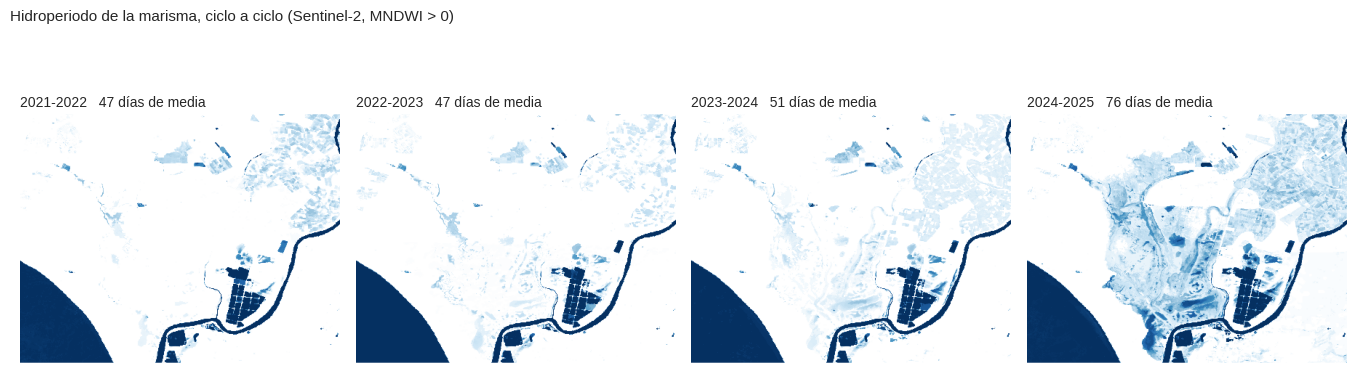

In [10]:
fig, axes = plt.subplots(1, len(ciclos), figsize=(3.4 * len(ciclos), 4.2))
for ax, (anio, imagen) in zip(np.atleast_1d(axes), ciclos.items()):
    ax.imshow(miniatura(imagen.select('normalized'), HYD_VIS, roi))
    ax.set_title('%d-%d   %.0f días de media'
                 % (anio, anio + 1,
                    resumen.loc['%d-%d' % (anio, anio + 1)].iloc[0]),
                 loc='left', fontsize=10)
    ax.axis('off')
fig.suptitle('Hidroperiodo de la marisma, ciclo a ciclo (Sentinel-2, MNDWI > 0)',
             x=0.005, ha='left', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Ahí está la sequía y ahí está la salida de la sequía: **47 días** de hidroperiodo medio en
2021-22 y en 2022-23, **51** en 2023-24 y **76** en 2024-25. El ciclo húmedo tiene un 61 %
más de inundación media que los secos, y eso en una marisma no es un número bonito: son los
caños y las zonas someras volviendo a tener agua el tiempo suficiente para que críen las
aves.

Dos avisos antes de usar la cifra. El hidroperiodo que se compara entre ciclos es el
**normalizado**: el crudo depende de cuántos días del año tuvieron dato. Y el número de
escenas cambia mucho de un ciclo a otro —38 en 2022-23, 53 en 2024-25—, lo que no quiere
decir que el ciclo con más escenas esté mejor medido: lo que importa es cómo se reparten a
lo largo del año, y a eso le pone número el IRT de la última sección.

## 5. Media y anomalías

Con varios ciclos ya se puede hablar de lo normal y de lo raro. `compute_anomalies()`
devuelve el hidroperiodo medio y, para cada ciclo, su desviación en días respecto a esa
media. Rojo = más seco de lo normal, azul = más inundado.

In [11]:
anomalias = ha_multi.compute_anomalies(cycles=ciclos)
media, desviaciones = anomalias['mean'], anomalias['anomalies']

Map4 = geemap.Map()
Map4.centerObject(roi, zoom=10)
Map4.addLayer(media, HYD_VIS, 'Hidroperiodo medio')
for anio, anomalia in desviaciones.items():
    Map4.addLayer(anomalia, ANOM_VIS, 'Anomalía %d-%d' % (anio, anio + 1), shown=False)
Map4.add_colorbar(ANOM_VIS, label='anomalía en días  (azul = más inundado)',
                  orientation='horizontal')
Map4

Map(center=[37.02507800413587, -6.3250000000004905], controls=(WidgetControl(options=['position', 'transparent…

## 6. ¿Me puedo creer el número? El IRT

Un hidroperiodo calculado con seis escenas mal repartidas no vale lo mismo que uno con
treinta. El **índice de representatividad temporal** (IRT) pone número a eso: 1 es
cobertura perfecta, y baja cuando las escenas se agolpan o dejan huecos largos.

Hay dos: uno global por ciclo y uno por píxel, que es el que enseña *dónde* no te puedes
fiar.

Mira el orden que sale: el ciclo con más escenas (2024-25, con 53) es el que **peor** IRT
tiene. No es una contradicción — el IRT no cuenta imágenes, mide cómo se reparten por el
año, y un año húmedo es un año nublado: justo en los meses de inundación es cuando se
pierden escenas y se abren los huecos.

In [12]:
for anio in sorted(ciclos):
    print('IRT %d-%d: %.3f' % (anio, anio + 1, ha_multi.compute_irt_global(hyd_year=anio)))

IRT 2021-2022: 0.818


IRT 2022-2023: 0.782


IRT 2023-2024: 0.713


IRT 2024-2025: 0.663


In [13]:
ha_multi.get_water_masks(index='mndwi', threshold=0.0, hyd_year=2024)
irt = ha_multi.compute_irt_image(hyd_year=2024)

IRT_VIS = {'bands': ['irt'], 'min': 0, 'max': 1,
           'palette': ['d7191c', 'fdae61', 'ffffbf', 'abd9e9', '2c7bb6']}
Map5 = geemap.Map()
Map5.centerObject(roi, zoom=10)
Map5.addLayer(irt, IRT_VIS, 'IRT por píxel, 2024-25')
Map5.add_colorbar(IRT_VIS, label='IRT  (1 = cobertura perfecta)', orientation='horizontal')
Map5

Map(center=[37.02507800413587, -6.3250000000004905], controls=(WidgetControl(options=['position', 'transparent…

## 7. Para llevárselo: series largas y exportación

Sentinel-2 empieza en 2017. Para ir más atrás se cambia una sola palabra —
`sat='Landsat'`— y se tienen ciclos desde 1984, a 30 m en lugar de 10. MODIS llega a 2000
y a 500 m.

Y lo que sale de aquí se exporta como cualquier imagen de Earth Engine:

```python
ha.export_to_drive(folder='donana_hidroperiodo',
                   description='hidroperiodo_2024_2025',
                   scale=10, crs='EPSG:25829')     # UTM 29N
ha.export_to_asset(asset_id='projects/tu-proyecto/assets/hidroperiodo_2024_25')
```

In [14]:
ns_ls = NdviSeasonality(roi=roi, sat='Landsat', start_year=2000, end_year=2003,
                        index='mndwi', cloud_filter=True)
ciclos_ls = HydroperiodAnalyzer(ns_ls).compute_all_cycles(index='mndwi', threshold=0.0)

Map6 = geemap.Map()
Map6.centerObject(roi, zoom=10)
for anio, imagen in ciclos_ls.items():
    Map6.addLayer(imagen.select('normalized'), HYD_VIS,
                  'Landsat %d-%d' % (anio, anio + 1), shown=anio == min(ciclos_ls))
Map6.add_colorbar(HYD_VIS, label='días de inundación', orientation='horizontal')
Map6

There we go again...
Applying cloud filter to Landsat: max 20% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering
Computing hydroperiod cycle 2000/2001…
Computing hydroperiod cycle 2001/2002…
Computing hydroperiod cycle 2002/2003…
Computing hydroperiod cycle 2003/2004…


Map(center=[37.02507800413587, -6.3250000000004905], controls=(WidgetControl(options=['position', 'transparent…

## Resumen

| para esto | se usa |
|---|---|
| máscaras de agua con sus pesos | `ha.get_water_masks(index, threshold, hyd_year)` |
| un ciclo | `ha.compute_hydroperiod(hyd_year=AAAA)` |
| todos los ciclos del rango | `ha.compute_all_cycles()` |
| media y anomalías | `ha.compute_anomalies(cycles=ciclos)` |
| fiabilidad temporal | `ha.compute_irt_global()` / `ha.compute_irt_image()` |
| sacarlo de Earth Engine | `ha.export_to_drive()` / `ha.export_to_asset()` |

Índices de agua disponibles: `ndwi`, `mndwi`, `awei`, `aweinsh`, `wi2015`.
Satélites: `S2` (10 m, desde 2017), `Landsat` (30 m, desde 1984), `MODIS` (500 m, desde 2000).

El año hidrológico empieza el 1 de septiembre; para otras latitudes se cambia al
construir el analizador: `HydroperiodAnalyzer(ns, hydrological_year_start=(4, 1))`.

- El libro, con la versión larga de este tutorial:
  **https://digdgeo.github.io/Ndvi2Gif/**
- Siguiente: `03_fenologia.ipynb`